# Day 15 — PCM Basics in Python
**Mahesha Gonal — Refrigeration Simulation Portfolio**

Models the latent-heat energy storage behaviour of a phase change material (PCM) — the physics behind the PCM patent (202521124792) — and quantifies why a PCM pack outperforms an equal mass of water as a thermal buffer.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.2 MB/s eta 0:00:00


In [2]:
# CELL 2 — Imports
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — PCM material properties (typical paraffin-based PCM for cold packs)
T_melt   = 5.0       # °C, melting/freezing point — tuned for refrigerator PCM packs
c_solid  = 2.0e3      # J/kg.K, specific heat below melting point
c_liquid = 2.2e3      # J/kg.K, specific heat above melting point
L_fusion = 200e3      # J/kg, latent heat of fusion
m_pcm    = 0.3        # kg, mass of PCM pack
melt_band = 1.0       # °C, narrow band over which melting is modeled (numerical smoothing)

In [4]:
# CELL 4 — Energy stored as a function of temperature (sensible + latent + sensible)
def energy_stored(T_array, T_ref=-10.0):
    """Cumulative energy absorbed by the PCM pack heating from T_ref to T."""
    energies = np.zeros_like(T_array, dtype=float)
    for i, T in enumerate(T_array):
        if T <= T_melt - melt_band/2:
            energies[i] = m_pcm * c_solid * (T - T_ref)
        elif T >= T_melt + melt_band/2:
            e_solid  = m_pcm * c_solid * ((T_melt - melt_band/2) - T_ref)
            e_latent = m_pcm * L_fusion
            e_liquid = m_pcm * c_liquid * (T - (T_melt + melt_band/2))
            energies[i] = e_solid + e_latent + e_liquid
        else:
            e_solid = m_pcm * c_solid * ((T_melt - melt_band/2) - T_ref)
            frac = (T - (T_melt - melt_band/2)) / melt_band
            energies[i] = e_solid + frac * m_pcm * L_fusion
    return energies

T_range = np.linspace(-10, 20, 300)
E_pcm = energy_stored(T_range)

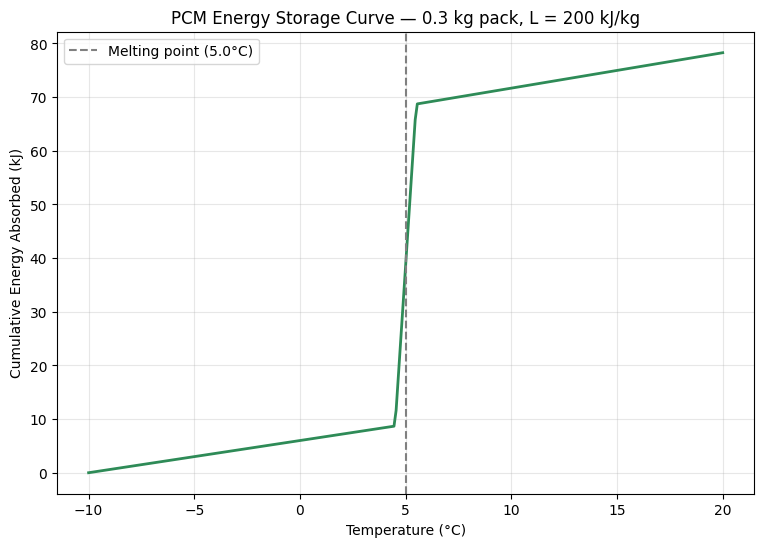

In [5]:
# CELL 5 — Plot: Energy absorbed vs Temperature (the PCM "plateau")
plt.figure(figsize=(9, 6))
plt.plot(T_range, E_pcm/1000, color='seagreen', linewidth=2)
plt.axvline(T_melt, linestyle='--', color='gray', label=f'Melting point ({T_melt}°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Cumulative Energy Absorbed (kJ)')
plt.title(f'PCM Energy Storage Curve — {m_pcm} kg pack, L = {L_fusion/1000:.0f} kJ/kg')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# CELL 6 — Why PCM beats an equal mass of water as a thermal buffer
c_water = 4186  # J/kg.K
T_start, T_end = -5.0, 10.0

E_pcm_swing = energy_stored(np.array([T_end]))[0] - energy_stored(np.array([T_start]))[0]
E_water_swing = m_pcm * c_water * (T_end - T_start)

print(f"Energy absorbed by {m_pcm} kg PCM pack from {T_start}°C to {T_end}°C: {E_pcm_swing/1000:.1f} kJ")
print(f"Energy an equal mass of water would absorb over the same swing:      {E_water_swing/1000:.1f} kJ")
print(f"PCM absorbs {E_pcm_swing/E_water_swing:.1f}x more energy for the same mass and temperature swing")

Energy absorbed by 0.3 kg PCM pack from -5.0°C to 10.0°C: 68.7 kJ
Energy an equal mass of water would absorb over the same swing:      18.8 kJ
PCM absorbs 3.6x more energy for the same mass and temperature swing


In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

# Pull the CURRENT notebook's content directly from Colab's frontend --
# works even though the .ipynb was never saved as a file on the VM disk
nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day15_pcm_basics.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 15 - PCM basics", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 15 - PCM basics", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")